# MLDoctor - Case2
For an automated retail kiosk that recommends a new look based on a user’s current appearance, the development team developed a classifier to detect whether an individual is wearing eyeglasses, enabling the system to suggest suitable frame styles as part of the recommendation. During internal “Lab Phase” testing, the model achieved near-perfect accuracy on the company’s validation set. Engineers also observed that its performance remained stable across different lighting conditions and head poses. However, within weeks of deployment, the results from the kiosks were puzzling. While the model worked reliably for some users, its accuracy dropped significantly for others. Even more confusingly, these errors occurred in clear, well-lit images similar to those used during internal testing. Please elaborate on the identified problem, explain how it was identified, and provide a recommended solution.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd
import seaborn as sns

#import torch which has many of the functions to build deep learning models and to train them
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

#import torchvision, which was lots of functions for loading and working with image data
import torchvision
import torchvision.transforms as transforms

#this is a nice progress bar representation that will be good to measure progress during training
import tqdm
import copy
import random

# fix seed for reproducibility
torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

# setup device
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu') #this line checks if we have a GPU available
print(f"Using device: {device}")

Using device: cuda:0


## Data

In [2]:
# Load the full training dataset first (without transforms for now)
test_internal_dataset = torchvision.datasets.ImageFolder('Case2Dataset/test_internal')
print(f'Validation dataset size: {len(test_internal_dataset)}')
test_external_dataset = torchvision.datasets.ImageFolder('Case2Dataset/test_external')
print(f'Test external dataset size: {len(test_external_dataset)}')

# Imnagenet preprocessing
imagenet_means = (0.485, 0.456, 0.406)
imagenet_stds = (0.229, 0.224, 0.225)

# preprocessing transform
transform = transforms.Compose(
    [transforms.ToTensor(),
    transforms.Resize((224, 224)), 
    transforms.Normalize(imagenet_means, imagenet_stds)])


# Apply transforms to the datasets
test_internal_dataset.transform = transform
test_external_dataset.transform = transform

# create dataloaders for train, val, test datasets
batch_size = 16
test_internal_loader = torch.utils.data.DataLoader(test_internal_dataset, batch_size=batch_size, shuffle=False, num_workers = 1)
test_external_loader = torch.utils.data.DataLoader(test_external_dataset, batch_size=batch_size, shuffle=False, num_workers = 1)

Validation dataset size: 300
Test external dataset size: 300


## Developed Model

In [3]:
def setup_model(model, num_classes, freeze_backbone = False):
    
    #### Adapt the architecture for the new number of classes.
    in_features = model.fc.in_features
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    #### If necessary, freeze any weights.
    if freeze_backbone: 
        for param in model.parameters():
            param.requires_grad = False
        
        # Unfreeze the parameters of the last fully connected layer
        for param in model.fc.parameters():
            param.requires_grad = True

    return model

# setup the model
backbone = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)
resnet_frozen = setup_model(backbone, 2, False)

# Load the developed model
resnet_frozen.load_state_dict(torch.load("resnet_frozen_best.pth"))
resnet_frozen.eval()
resnet_frozen = resnet_frozen.to(device)
print(resnet_frozen)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /tmp/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 389MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

## Evaluation

In [4]:
# Load the best model
resnet_frozen.eval()

# Collect predictions and ground truth labels
all_predictions = {'internal': [], 'external': []}
all_labels = {'internal': [], 'external': []}

# compute predictions
with torch.no_grad():
    for split, dataloader in zip(['internal', 'external'], [test_internal_loader, test_external_loader]):
        for data in tqdm.tqdm(dataloader, desc=f'Evaluating on {split} set'):
            inputs, labels = data
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = resnet_frozen(inputs)
            probs = torch.softmax(outputs, dim=1)

            all_predictions[split].append(probs.cpu().numpy())
            all_labels[split].append(labels.cpu().numpy())
print("Evaluation complete.")

for split in ['internal', 'external']:
    all_predictions[split] = np.concatenate(all_predictions[split], axis=0)
    all_labels[split] = np.concatenate(all_labels[split], axis=0)
    predicted_classes = np.argmax(all_predictions[split], axis=1)
    accuracy = (predicted_classes == all_labels[split]).mean()
    print(f"{split} set - Accuracy: {accuracy:.3f}")

Evaluating on external set: 100%|██████████| 19/19 [00:01<00:00, 13.74it/s]

Evaluation complete.
internal set - Accuracy: 0.987
external set - Accuracy: 0.710


### This is where i will check the dataset 

In [5]:
## Checking dataset information 

all_predictions['internal']
all_predictions['external']

all_labels['internal']
all_labels['external']

for split in ['internal', 'external']:
    labels = all_labels[split]

    print(f"\n{split.upper()} DATASET")
    print(f"Number of samples: {len(labels)}")
    print(f"Label shape: {labels.shape}")
    print(f"Unique labels: {np.unique(labels, return_counts=True)}")


INTERNAL DATASET
Number of samples: 300
Label shape: (300,)
Unique labels: (array([0, 1]), array([150, 150]))

EXTERNAL DATASET
Number of samples: 300
Label shape: (300,)
Unique labels: (array([0, 1]), array([150, 150]))


In [6]:
## We want to confirm the class mappings 

print(test_internal_loader.dataset.classes)
print(test_external_loader.dataset.classes)

['negative', 'positive']
['negative', 'positive']


In [7]:
## Check for class distribution 

from collections import Counter

for split in ['internal', 'external']:
    counts = Counter(all_labels[split])

    print(f"\n{split.upper()}")
    for label, count in sorted(counts.items()):
        percentage = count / len(all_labels[split]) * 100
        print(f"Class {label}: {count} ({percentage:.2f}%)")


INTERNAL
Class 0: 150 (50.00%)
Class 1: 150 (50.00%)

EXTERNAL
Class 0: 150 (50.00%)
Class 1: 150 (50.00%)


In [8]:
for split in ['internal', 'external']:
    predicted_classes = np.argmax(all_predictions[split], axis=1)

    unique, counts = np.unique(predicted_classes, return_counts=True)

    print(f"\n{split.upper()} PREDICTIONS")

    for label, count in zip(unique, counts):
        percentage = count / len(predicted_classes) * 100
        print(f"Class {label}: {count} ({percentage:.2f}%)")


INTERNAL PREDICTIONS
Class 0: 154 (51.33%)
Class 1: 146 (48.67%)

EXTERNAL PREDICTIONS
Class 0: 177 (59.00%)
Class 1: 123 (41.00%)


### This is where i will check the models 

In [9]:
## imports 
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report



===== INTERNAL =====
Samples: 300
True labels: (array([0, 1]), array([150, 150]))
Predicted labels: (array([0, 1]), array([154, 146]))
Confusion matrix:

===== EXTERNAL =====
Samples: 300
True labels: (array([0, 1]), array([150, 150]))
Predicted labels: (array([0, 1]), array([177, 123]))
Confusion matrix:


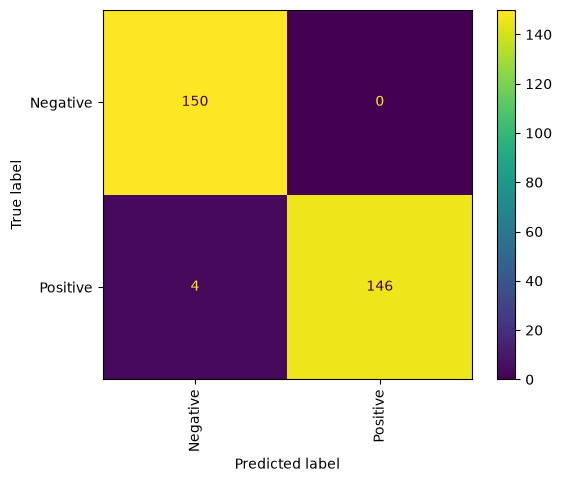

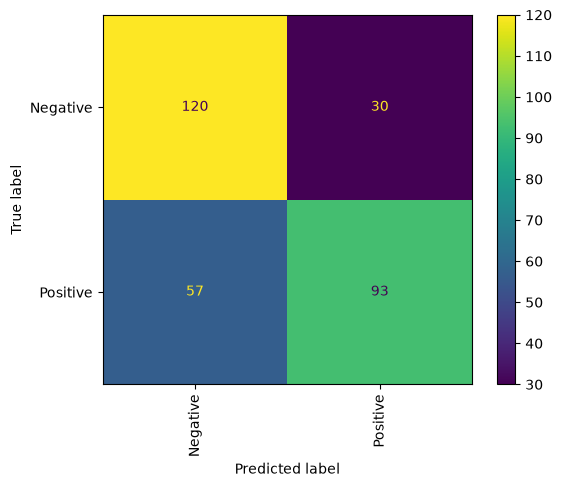

In [10]:
for split in ['internal', 'external']:

    labels = all_labels[split]
    predictions = all_predictions[split]
    predicted_classes = np.argmax(predictions, axis=1)

    print(f"\n===== {split.upper()} =====")

    print("Samples:", len(labels))
    print("True labels:", np.unique(labels, return_counts=True))
    print("Predicted labels:", np.unique(predicted_classes, return_counts=True))
    print("Confusion matrix:")
    print(ConfusionMatrixDisplay.from_predictions(labels, predicted_classes, display_labels=['Negative', 'Positive'], xticks_rotation='vertical'))

In [11]:
for split in ['internal', 'external']:

    labels = all_labels[split]
    predictions = all_predictions[split]
    predicted_classes = np.argmax(predictions, axis=1)

    print(f"\n===== {split.upper()} =====")

    print(classification_report(
        labels,
        predicted_classes,
        target_names=['Negative', 'Positive'],
        digits=3
    ))


===== INTERNAL =====
              precision    recall  f1-score   support

    Negative      0.974     1.000     0.987       150
    Positive      1.000     0.973     0.986       150

    accuracy                          0.987       300
   macro avg      0.987     0.987     0.987       300
weighted avg      0.987     0.987     0.987       300


===== EXTERNAL =====
              precision    recall  f1-score   support

    Negative      0.678     0.800     0.734       150
    Positive      0.756     0.620     0.681       150

    accuracy                          0.710       300
   macro avg      0.717     0.710     0.708       300
weighted avg      0.717     0.710     0.708       300



In [12]:
import cv2
import numpy as np

def calculate_sharpness(image):

    # Tensor -> NumPy
    image = image.detach().cpu().numpy()

    # C x H x W -> H x W x C
    image = np.transpose(image, (1, 2, 0))

    # Convert RGB -> grayscale
    image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    # Ensure correct datatype
    image = image.astype(np.float32)

    # Calculate sharpness
    return cv2.Laplacian(image, cv2.CV_32F).var()

In [13]:
internal_sharpness = []

for image, label in test_internal_dataset:
    internal_sharpness.append(calculate_sharpness(image))

external_sharpness = []

for image, label in test_external_dataset:
    external_sharpness.append(calculate_sharpness(image))

In [14]:
print("Internal:", len(internal_sharpness))
print("External:", len(external_sharpness))

print("\nINTERNAL")
print("Mean:", np.mean(internal_sharpness))
print("Median:", np.median(internal_sharpness))

print("\nEXTERNAL")
print("Mean:", np.mean(external_sharpness))
print("Median:", np.median(external_sharpness))

Internal: 300
External: 300

INTERNAL
Mean: 0.08191809
Median: 0.062911324

EXTERNAL
Mean: 0.07678633
Median: 0.058559477
